# Introdução à Inteligência Artificial e Fundamentos de Python

## Regressão Linear em Aprendizado de Máquina - Continuação

### $R^2$, *R-Squared* ou R-quadrado

Segundo a wikipedia, a definição de $R^2$ é: 
* Na estatística, o coeficiente de determinação — denotado por R² ou r² e pronunciado como "R ao quadrado" — é a proporção da variação na variável dependente que pode ser prevista a partir da(s) variável(is) independente(s). Trata-se de uma medida estatística utilizada no contexto de modelos cujo objetivo principal é a previsão de resultados futuros ou o teste de hipóteses, com base em outras informações relacionadas. Ele fornece uma medida de quão bem os resultados observados são reproduzidos pelo modelo, com base na proporção da variação total dos resultados explicada pelo modelo.

A definição matemática de $R^2$ é:
$$R^2=1-\frac{SS_{res}}{SS_{tot}},$$
onde $SS_{res}$ é a soma dos erros ao quadrado do modelo, ou soma residual dos quadrados, e é dada por:
$$SS_{res}=\sum_{i=1}^n(y_i-\hat{y}_i)^2.$$
Finalmente, $SS_{tot}$ é a soma total dos quadrados, ou a soma das diferenças entre as varáveis $y_i $ e a média $\bar{y}$,
$$SS_{tot}=\sum_{i=1}^n(y_i-\bar{y})^2.$$

Agora, no melhor caso o modelo preve todas as saídas dos dados perfeitamente implicando $SS_{res}=0$ e daí $R^2=1$. Quando $SS_{res}=SS_{tot}$, o modelo não está sendo capaz de fazer mais do que simplesmente predizer a média dos dados de entrada, e portanto, $R^2=0$.  Finalmente, poderia acontecer de $SS_{res} \gt SS_{tot}$, ou seja, as predições do modelo são piores do que prever a média, e dependendo desta relação, o valor de $R^2$ poderia ser negativo.  


### Implementação de um modelo de Regressão Linear Simples

Incialmente, como sempre, importamos as bibliottecas necessárias:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Em seguida, definimos uma Classe em Python para determinação do modelo, composta de três métodos:
*  _ _init_ _: inicializa os atributos da classe.
* fit : Calcula a inclinação e a intersecção com a Equação Norma; vista na aula anterior, e avalia $R^2$.
* predict : Calcula as predições com base nos coeficientes aprendidos no método anterior. 

In [2]:
class LinearRegression:
    def __init__(self):
        # Qualquer objeto dessa classe possui esses três atributos, embora eles ainda não tenham sido calculados.
        self.coefficients = None
        self.r2 = None
        self.y_pred=None

    def fit(self, X, y):
        n = len(X)
        X_b = np.c_[np.ones((n,1)), X]  

        self.coefficients = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
        self.y_pred = X_b.dot(self.coefficients)
        # R²
        self.r2 = 1 - (np.sum((y - self.y_pred)**2) / np.sum((y - np.mean(y))**2))

    def predict(self, X):
        X_b = np.c_[np.ones((len(X),1)), X]
        return X_b.dot(self.coefficients)

Aplicação à um conjunto de treino:

In [3]:
X = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)
# Obs: np.array([1,2,3,4,5,6,7,8,9,10]) define um array (10,) NumPy de uma única dimensão (vetor), contendo 10 elementos. 
# reshape(-1,1) diz ao NumPy para transformar o array original em um array (matriz) com 10 colunas, e o número de linhas necessárias (-1).
y = np.array([2,4,5,4,5,7,8,9,10,12])

slr = LinearRegression()
slr.fit(X, y)

Visualização dos resultados:

LR Coefficients: [1.06666667 1.00606061]
R² Score: 0.94


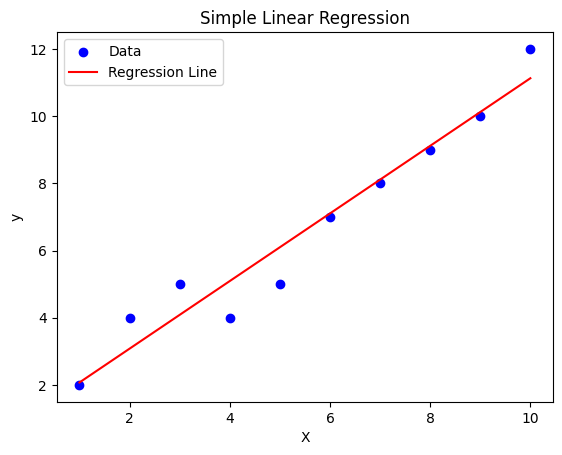

In [4]:
print(f"LR Coefficients: {slr.coefficients}")
print(f"R² Score: {slr.r2:.2f}")

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, slr.y_pred, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

* Um segundo exemplo, onde a distribuição dos pontos no eixo y pode ser variada randomicamente:

In [5]:
np.random.seed(40)
x=np.linspace(-0.5,0.5,70)
y = 4 + 3 * x + 0.5*np.random.randn(70)/1.5
X=x.reshape(-1,1)

slr = LinearRegression()
slr.fit(X, y)

LR Coefficients: [4.01919227 2.98425094]
R² Score: 0.89


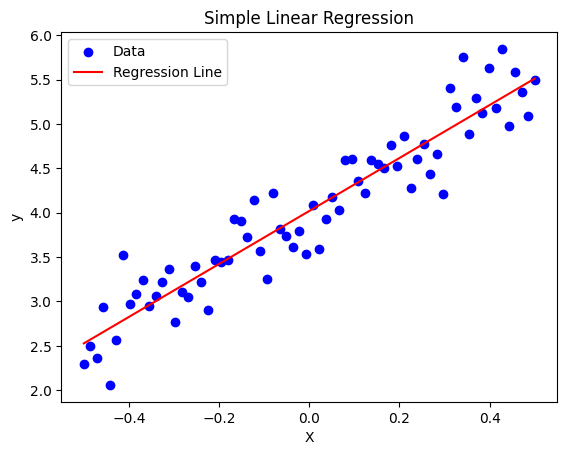

In [6]:
print(f"LR Coefficients: {slr.coefficients}")
print(f"R² Score: {slr.r2:.2f}")

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, slr.y_pred, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

* Neste exemplo, tentamos usar a regressão linear para o ajuste de pontos ditribuídos quadraticamente:

In [7]:
np.random.seed(42)
num_points = 50
x = np.linspace(-0.5,0.5, num_points)
y = (x)**2
X=x.reshape(-1,1)

slr = LinearRegression()
slr.fit(X, y)

LR Coefficients: [ 8.67346939e-02 -7.63278329e-17]
R² Score: 0.00


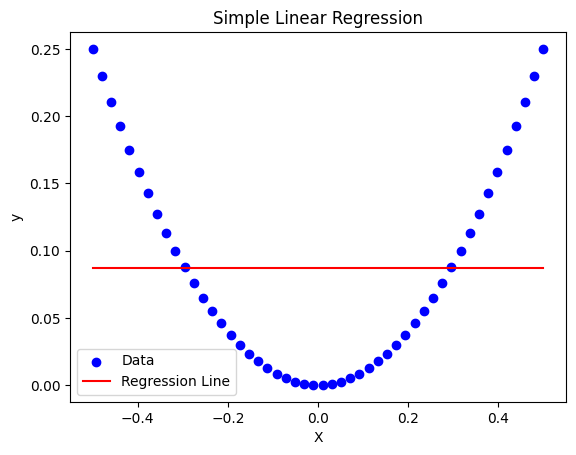

In [8]:
print(f"LR Coefficients: {slr.coefficients}")
print(f"R² Score: {slr.r2:.2f}")

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, slr.y_pred, color='red', label='Regression Line')
plt.title("Simple Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()